# PCA on a large column dataset

In [79]:
# Basic Liabraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import accuracy_score

In [80]:
# reading the dataset
data=pd.read_csv("ultrasound_1.csv")

In [82]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1577 entries, 0 to 1576
Columns: 577 entries, 0 to Pass/Fail
dtypes: float64(576), int64(1)
memory usage: 6.9 MB


In [83]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2973.86,2359.01,2196.6555,1066.1908,1.2188,100.0,101.8900,0.1215,1.4544,-0.0052,...,NaN,0.5025,0.0128,0.0040,2.5391,0.0199,0.0117,0.0043,58.5665,1
1,3052.82,2525.33,2186.2667,1088.7359,1.2723,100.0,103.5633,0.1216,1.4891,-0.0007,...,131.2543,0.5003,0.0150,0.0043,2.9976,0.0228,0.0299,0.0105,131.2543,-1
2,2914.47,2492.14,2181.6111,1083.3937,1.2484,100.0,104.1478,0.1219,1.5568,-0.0214,...,NaN,0.4939,0.0136,0.0037,2.7633,0.0228,0.0299,0.0105,131.2543,-1
3,2959.86,2491.19,2208.0000,1835.9832,1.5714,100.0,100.2478,0.1239,1.4680,0.0033,...,128.2819,0.4993,0.0138,0.0038,2.7630,0.0140,0.0180,0.0054,128.2819,1
4,2964.77,2524.44,2181.5111,1177.0830,1.3012,100.0,100.9333,0.1216,1.4047,-0.0080,...,NaN,0.4984,0.0155,0.0040,3.1012,0.0140,0.0180,0.0054,128.2819,1


In [6]:
#pd.set_option("display.max_columns",600)
#pd.set_option("display.max_rows",600)

In [84]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2973.86,2359.01,2196.6555,1066.1908,1.2188,100.0,101.8900,0.1215,1.4544,-0.0052,...,NaN,0.5025,0.0128,0.0040,2.5391,0.0199,0.0117,0.0043,58.5665,1
1,3052.82,2525.33,2186.2667,1088.7359,1.2723,100.0,103.5633,0.1216,1.4891,-0.0007,...,131.2543,0.5003,0.0150,0.0043,2.9976,0.0228,0.0299,0.0105,131.2543,-1
2,2914.47,2492.14,2181.6111,1083.3937,1.2484,100.0,104.1478,0.1219,1.5568,-0.0214,...,NaN,0.4939,0.0136,0.0037,2.7633,0.0228,0.0299,0.0105,131.2543,-1
3,2959.86,2491.19,2208.0000,1835.9832,1.5714,100.0,100.2478,0.1239,1.4680,0.0033,...,128.2819,0.4993,0.0138,0.0038,2.7630,0.0140,0.0180,0.0054,128.2819,1
4,2964.77,2524.44,2181.5111,1177.0830,1.3012,100.0,100.9333,0.1216,1.4047,-0.0080,...,NaN,0.4984,0.0155,0.0040,3.1012,0.0140,0.0180,0.0054,128.2819,1


In [8]:
# missing value checking

In [85]:
#finding misisng value
data.isnull().sum().sum()

42093

In [86]:
# handling missing value replacing all the Nan VALUES WITH 0 .
#data=data.replace(np.NaN,0)
#data=data.fillna(data.mean())
data=data.fillna(data.median())
data.isna().sum().sum()

0

In [ ]:
# visualization of dependent variable

In [87]:
unique_vals=data["Pass/Fail"].unique()
unique_vals

array([ 1, -1], dtype=int64)

In [ ]:
# converting target variable assigning 0 - pass and 1 - fail in quality testing.

In [88]:
data["Pass/Fail"]=data["Pass/Fail"].map({-1:0,1:1})

In [89]:
data["Pass/Fail"].value_counts()

0    1472
1     105
Name: Pass/Fail, dtype: int64

In [ ]:
# dependent and independent 

In [90]:
X=data.drop("Pass/Fail",axis=1)
Y=data["Pass/Fail"]

In [91]:
scaler1 = StandardScaler()
X_s = scaler1.fit_transform(X)

In [92]:
# before apply pca

# splitting the dataset into training and test data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X_s,Y,test_size=0.25,random_state=101,stratify=Y)

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train, y_train)

RandomForestClassifier()

In [93]:
# predicting the test set result
y_pred=rf.predict(x_test)
# creating confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[369,   0],
       [ 25,   1]], dtype=int64)

In [94]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

print("CLASSIFIER TESTING ACCURACY ",accuracy_score(y_test,y_pred))

CLASSIFIER TESTING ACCURACY  0.9367088607594937


In [95]:
print("classification report ",classification_report(y_test,y_pred))

classification report                precision    recall  f1-score   support

           0       0.94      1.00      0.97       369
           1       1.00      0.04      0.07        26

    accuracy                           0.94       395
   macro avg       0.97      0.52      0.52       395
weighted avg       0.94      0.94      0.91       395



# Apply PCA

In [96]:
from sklearn.decomposition import PCA
pca = PCA()
pca = pca.fit(X_s)

In [97]:
pca.explained_variance_ratio_

array([5.47619431e-02, 3.67908024e-02, 2.82218597e-02, 2.55737668e-02,
       2.19366553e-02, 2.06178324e-02, 1.98226948e-02, 1.81043933e-02,
       1.66654380e-02, 1.60465321e-02, 1.47602898e-02, 1.33419303e-02,
       1.30917975e-02, 1.28967098e-02, 1.26620972e-02, 1.19900323e-02,
       1.14977172e-02, 1.13022167e-02, 1.10211838e-02, 1.05313350e-02,
       1.02022626e-02, 1.00221357e-02, 9.99030418e-03, 9.72173593e-03,
       9.48280146e-03, 9.32655112e-03, 9.26824367e-03, 8.93172316e-03,
       8.60495851e-03, 8.52139026e-03, 8.35379041e-03, 8.19948086e-03,
       8.17067679e-03, 7.95315500e-03, 7.73919126e-03, 7.71940630e-03,
       7.58841353e-03, 7.51576432e-03, 7.30508346e-03, 7.18199965e-03,
       7.10675367e-03, 6.92018407e-03, 6.85616391e-03, 6.75614835e-03,
       6.69584300e-03, 6.57528035e-03, 6.42002097e-03, 6.26282159e-03,
       6.23643422e-03, 6.09915459e-03, 6.07748494e-03, 5.97626508e-03,
       5.91289830e-03, 5.71300082e-03, 5.66363859e-03, 5.54403443e-03,
      

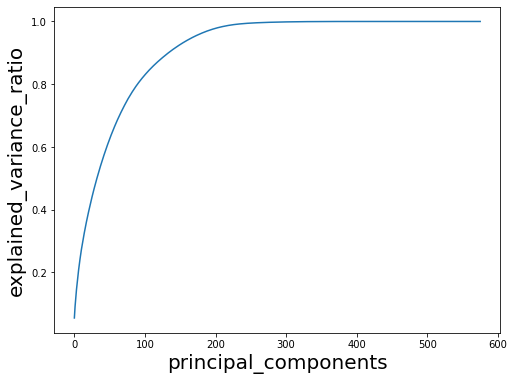

In [98]:
plt.figure(figsize=(8,6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.grid(False)
plt.xlabel('principal_components', fontsize=20)
plt.ylabel('explained_variance_ratio', fontsize=20)
plt.show()

In [ ]:
# calculation of principal components

In [99]:
pca_200 = PCA(n_components=200)
pca_applied = pca_200.fit_transform(X_s)

In [100]:
pca_applied_df = pd.DataFrame(data=pca_applied)

In [101]:
pca_applied_df.head()

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,-1.525916,3.696622,2.287973,-4.642870,0.438883,-2.808041,-2.453813,3.862617,5.115351,-0.857741,...,-0.478371,-0.255842,-0.677845,-0.754379,-0.589633,0.660674,-0.311935,-0.384935,-0.392437,-0.801383
1,-0.624775,1.680499,2.358534,-2.343379,0.532350,0.398344,-3.119943,0.124351,3.087616,-1.562967,...,-0.613945,-0.236214,-0.545409,-0.684705,0.347305,-0.000176,-0.012408,-0.077679,0.025012,-0.971670
2,-1.685583,2.408470,0.647352,-0.823922,-0.850029,-2.631963,-0.974666,3.344396,1.415521,-1.177684,...,0.313614,-0.155767,0.667527,0.312213,0.782570,0.422291,0.282541,-0.737811,-0.503845,0.117295
3,-2.094079,3.182130,0.875445,-2.815955,0.284866,-0.961272,-3.788064,0.780538,2.163029,-0.291415,...,-0.296682,0.084881,0.201914,-0.298372,-0.077656,-0.267481,0.115287,-0.323869,-0.637677,-0.328978
4,-1.041194,1.822960,1.100425,-2.793463,0.265398,-1.071624,-2.278647,0.174761,3.262954,-1.527872,...,-0.135633,-0.058741,0.410614,-0.434249,0.217413,-0.238989,0.599956,0.119231,0.740515,0.526574


In [102]:
explained_VR=pca_200.explained_variance_ratio_
explained_VR

array([0.05476194, 0.0367908 , 0.02822186, 0.02557377, 0.02193666,
       0.02061783, 0.01982269, 0.01810439, 0.01666544, 0.01604653,
       0.01476029, 0.01334193, 0.0130918 , 0.01289671, 0.0126621 ,
       0.01199003, 0.01149772, 0.01130222, 0.01102118, 0.01053133,
       0.01020226, 0.01002214, 0.0099903 , 0.00972174, 0.0094828 ,
       0.00932655, 0.00926824, 0.00893172, 0.00860496, 0.00852139,
       0.00835379, 0.00819948, 0.00817068, 0.00795315, 0.00773919,
       0.00771941, 0.00758841, 0.00751576, 0.00730508, 0.007182  ,
       0.00710675, 0.00692018, 0.00685616, 0.00675615, 0.00669584,
       0.00657528, 0.00642002, 0.00626282, 0.00623643, 0.00609915,
       0.00607748, 0.00597627, 0.0059129 , 0.005713  , 0.00566364,
       0.00554403, 0.0055091 , 0.0054417 , 0.00536152, 0.00526167,
       0.00515466, 0.00505619, 0.00494494, 0.00488774, 0.0048332 ,
       0.00471087, 0.00465393, 0.00461458, 0.00455297, 0.00444596,
       0.00440367, 0.00431531, 0.00429773, 0.00428534, 0.00419

In [103]:
#np.sum(pca_15.explained_variance_ratio_)
np.sum(explained_VR)

0.9774147093283159

In [ ]:
# after apply pca accuracy

In [104]:
# splitting the dataset into training and test data
from sklearn.model_selection import train_test_split
x_train1,x_test1,y_train1,y_test1=train_test_split(pca_applied_df,Y,test_size=0.25,random_state=101,stratify=Y)

In [105]:
from sklearn.ensemble import RandomForestClassifier

In [106]:
rf1=RandomForestClassifier()

In [107]:
rf1.fit(x_train1,y_train1)

RandomForestClassifier()

In [108]:
pred1=rf1.predict(x_test1)

In [109]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,pred1)
cm

array([[368,   1],
       [ 24,   2]], dtype=int64)

In [110]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

print("CLASSIFIER TESTING ACCURACY ",accuracy_score(y_test1,pred1))

CLASSIFIER TESTING ACCURACY  0.9367088607594937


In [111]:
print("classification report ",classification_report(y_test1,pred1))

classification report                precision    recall  f1-score   support

           0       0.94      1.00      0.97       369
           1       0.67      0.08      0.14        26

    accuracy                           0.94       395
   macro avg       0.80      0.54      0.55       395
weighted avg       0.92      0.94      0.91       395



# creating a copy of data set for learning purpose , not connected with the project

In [19]:
data100=data.copy()

In [19]:
# import SMOTE module from imblearn library
#!pip install imblearn 
#(if you don't have imblearn in your system)

In [20]:
""" three popular methods :- 
Undersampling
Oversampling
SMOTE sampling"""


' three popular methods :- \nUndersampling\nOversampling\nSMOTE sampling'

In [20]:
X = data100.drop(['Pass/Fail'],axis=1)
Y =data100['Pass/Fail']

In [21]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.30, stratify=Y, random_state = 100)

In [23]:
X_train.shape

(1103, 576)

In [24]:
Y_train.shape

(1103,)

In [25]:
from imblearn.over_sampling import SMOTE
sm=SMOTE()

# please note we only balance the training dataset , we should not balance the test dataset.

In [37]:
X_train_smote, Y_train_smote = sm.fit_resample(X,Y)

print("Bofore balancing X_train", X_train.shape)
print("*******"*5)
print("Bofore balancing Y_train", Y_train.shape)
print("*******"*5)
print(" no. of different class before balancing \n", Y_train.value_counts())
print("*******"*5)

Bofore balancing X_train (1103, 576)
***********************************
Bofore balancing Y_train (1103,)
***********************************
 no. of different class before balancing 
 0    1030
1      73
Name: Pass/Fail, dtype: int64
***********************************


In [38]:
print("after balancing X_train", X_train_smote.shape)
print("*******"*5)
print("after balancing Y_train",Y_train_smote.shape)

after balancing X_train (2944, 576)
***********************************
after balancing Y_train (2944,)


In [39]:
Y_train_smote.value_counts()

1    1472
0    1472
Name: Pass/Fail, dtype: int64

In [40]:
X_train.head()

,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
432,2999.89,2506.39,2178.6889,1657.3518,1.6603,100.0,100.8022,0.1229,1.4925,0.0203,...,0.0046,72.0230,0.5078,0.0159,0.0041,3.1216,0.0142,0.0156,0.0044,109.5996
1270,3062.36,2396.64,2173.2778,1116.2950,0.8525,100.0,103.8200,0.1237,1.4028,-0.0108,...,0.0046,72.0230,0.5029,0.0161,0.0047,3.1974,0.0184,0.0148,0.0054,80.1759
370,3109.46,2510.08,2197.6778,1056.7817,1.3168,100.0,102.9611,0.1203,1.5389,-0.0027,...,0.0049,331.6058,0.5016,0.0113,0.0034,2.2560,-0.0042,0.0138,0.0049,331.6058
959,3024.67,2620.96,2206.1444,1876.9899,2.0607,100.0,95.9511,0.1246,1.5648,0.0153,...,0.0046,72.0230,0.5050,0.0221,0.0047,4.3760,0.0260,0.0268,0.0068,103.3520
1077,3225.61,2493.13,2266.8333,2040.1937,1.6558,100.0,94.8489,0.1216,1.4162,0.0020,...,0.0046,72.0230,0.4991,0.0119,0.0030,2.3829,0.0276,0.0160,0.0053,57.7824


In [41]:
Y_train.head()

432     0
1270    0
370     0
959     0
1077    0
Name: Pass/Fail, dtype: int64

In [ ]:
"""smote technique work on KNN principal .we can see after apply of smote 
the minority class increse from 73 to 1030. 
now the dataset is balance we have equal no. of Minority and Majority class in training dataset."""

# Another method-Undersampling approach 

In [29]:
from imblearn.under_sampling import RandomUnderSampler
under=RandomUnderSampler()
X_train_under,Y_train_under=under.fit_resample(X_train,Y_train)
print(X_train_under.shape)
print(Y_train_under.shape)
print("After Random Undersampling method")
Y_train_under.value_counts()

(146, 576)
(146,)
After Random Undersampling method


0    73
1    73
Name: Pass/Fail, dtype: int64

In [ ]:
# undersampling approach reduce the majority class from 1030 to 73.
# now after undersample approach the dataset is balance we have majority class 73 and minitority class 73.

# another approach OVERsampling 

In [30]:
from imblearn.over_sampling import RandomOverSampler
over=RandomOverSampler()
X_train_over,Y_train_over=over.fit_resample(X_train,Y_train)
print(X_train_over.shape)
print(Y_train_over.shape)
print("After Random Over sampling Method")
Y_train_over.value_counts()

(2060, 576)
(2060,)
After Random Over sampling Method


0    1030
1    1030
Name: Pass/Fail, dtype: int64